In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [5]:
file_path="C:/Users/Admin/Downloads/WA_Fn-UseC_-Telco-Customer-Churn (1).csv"
df=pd.read_csv(file_path)
# Strip whitespace from column names
df.columns = df.columns.str.strip()

print("Initial shape:", df.shape)
print(df.head(3))

Initial shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No          No              No        One year   
2               No          No          No              No  Month-to-month   

  PaperlessBilling     PaymentMethod  MonthlyCharges TotalCharges Churn

In [6]:
# SECTION 3: DATA CLEANING AND PREPARATION
# 3.1 Fix TotalCharges — it is stored as text with blank spaces
# Convert to numeric, blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
print("TotalCharges missing after conversion:", df['TotalCharges'].isnull().sum())

# Fill missing TotalCharges with MonthlyCharges
# These are new customers with tenure=0 so their total equals their monthly charge
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# 3.2 Convert SeniorCitizen from 0/1 to Yes/No for readability
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 3.3 Create a numerical Churn column for calculations
# Yes = 1, No = 0
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3.4 Create Tenure Group column
# Groups customers by how long they have been with the company
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12 Months', '13-24 Months', '25-36 Months',
            '37-48 Months', '49-60 Months', '61-72 Months'],
    include_lowest=True
)

# 3.5 Create Monthly Charge Group column
df['Charge_Group'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 60, 90, 120],
    labels=['Low (0-30)', 'Medium (30-60)', 'High (60-90)', 'Very High (90+)']
)

print("\nCleaned shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nOverall churn rate: {df['Churn_Flag'].mean() * 100:.1f}%")

TotalCharges missing after conversion: 11

Cleaned shape: (7043, 24)

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'Tenure_Group', 'Charge_Group']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.5%


In [7]:
# SECTION 4: DESCRIPTIVE STATISTICS
print("\n--- Descriptive Statistics ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

print("\nMissing values:")
print(df.isnull().sum())


--- Descriptive Statistics ---
       tenure  MonthlyCharges  TotalCharges
count 7043.00         7043.00       7043.00
mean    32.37           64.76       2279.80
std     24.56           30.09       2266.73
min      0.00           18.25         18.80
25%      9.00           35.50        398.55
50%     29.00           70.35       1394.55
75%     55.00           89.85       3786.60
max     72.00          118.75       8684.80

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Flag          0
Tenure_Group        0
Charge_Group        0
dtype: int64


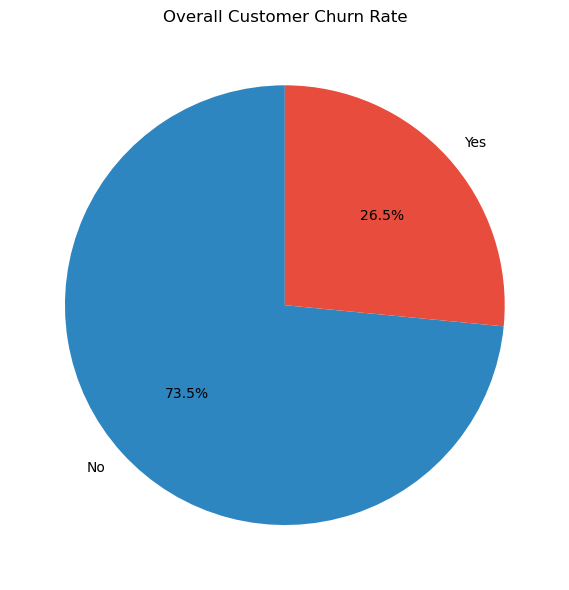

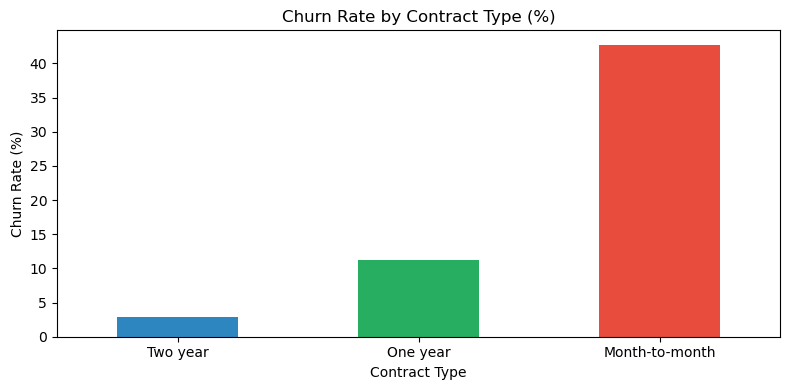

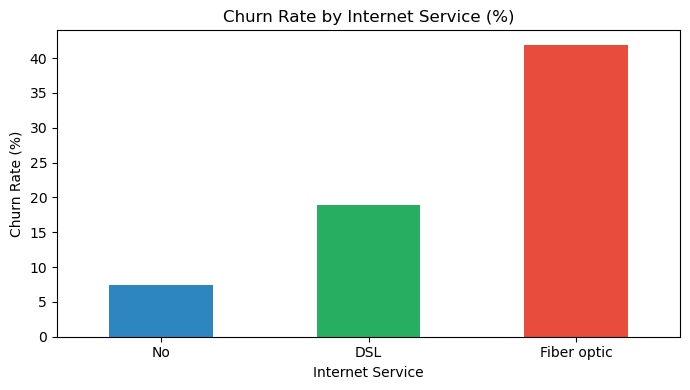

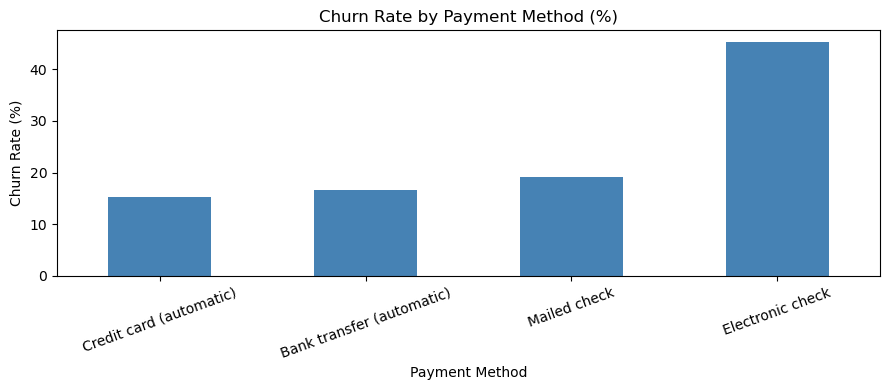

In [8]:
# SECTION 5: CHURN RATE ANALYSIS
# 5.1 Overall churn rate - Pie chart
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=['#2E86C1', '#E74C3C'],
    startangle=90
)
plt.title('Overall Customer Churn Rate')
plt.tight_layout()
plt.show()

# 5.2 Churn rate by Contract type
contract_churn = df.groupby('Contract')['Churn_Flag'].mean() * 100

plt.figure(figsize=(8, 4))
contract_churn.sort_values().plot(kind='bar', color=['#2E86C1', '#27AE60', '#E74C3C'])
plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5.3 Churn rate by Internet Service
internet_churn = df.groupby('InternetService')['Churn_Flag'].mean() * 100

plt.figure(figsize=(7, 4))
internet_churn.sort_values().plot(kind='bar', color=['#2E86C1', '#27AE60', '#E74C3C'])
plt.title('Churn Rate by Internet Service (%)')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5.4 Churn rate by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean() * 100

plt.figure(figsize=(9, 4))
payment_churn.sort_values().plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Payment Method (%)')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


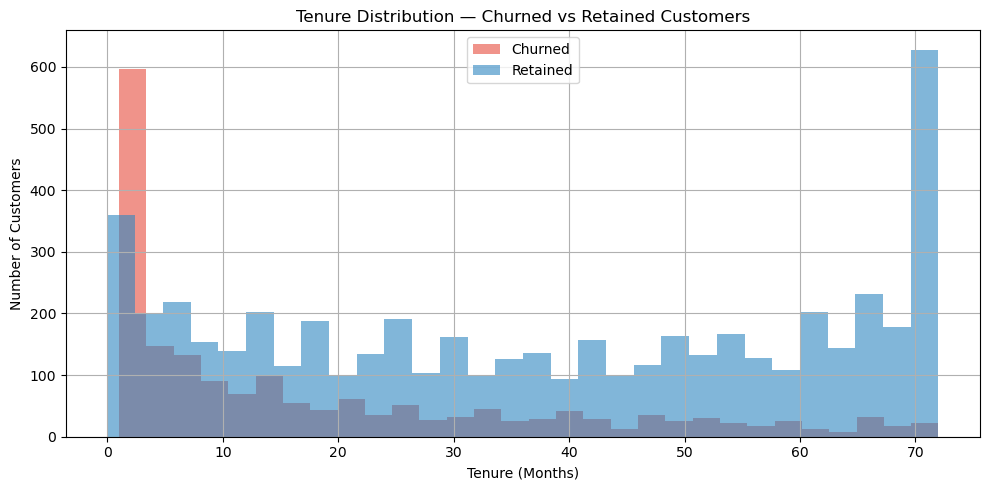

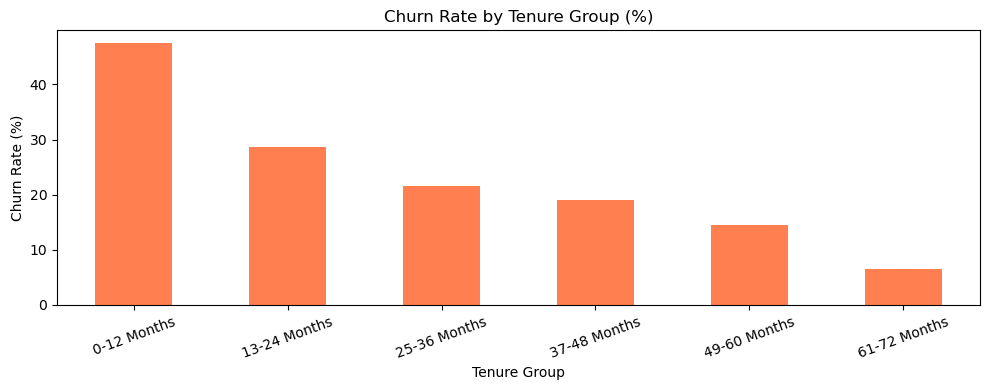


Average tenure (months):
Churn
No    37.57
Yes   17.98
Name: tenure, dtype: float64


In [9]:
# SECTION 6: TENURE AND LIFETIME ANALYSIS
# 6.1 Tenure distribution by churn status
plt.figure(figsize=(10, 5))
df[df['Churn'] == 'Yes']['tenure'].hist(
    bins=30, alpha=0.6, color='#E74C3C', label='Churned'
)
df[df['Churn'] == 'No']['tenure'].hist(
    bins=30, alpha=0.6, color='#2E86C1', label='Retained'
)
plt.title('Tenure Distribution — Churned vs Retained Customers')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

# 6.2 Churn rate by Tenure Group
tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn_Flag'].mean() * 100

plt.figure(figsize=(10, 4))
tenure_churn.plot(kind='bar', color='coral')
plt.title('Churn Rate by Tenure Group (%)')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 6.3 Average tenure — churned vs retained
avg_tenure = df.groupby('Churn')['tenure'].mean()
print("\nAverage tenure (months):")
print(avg_tenure)

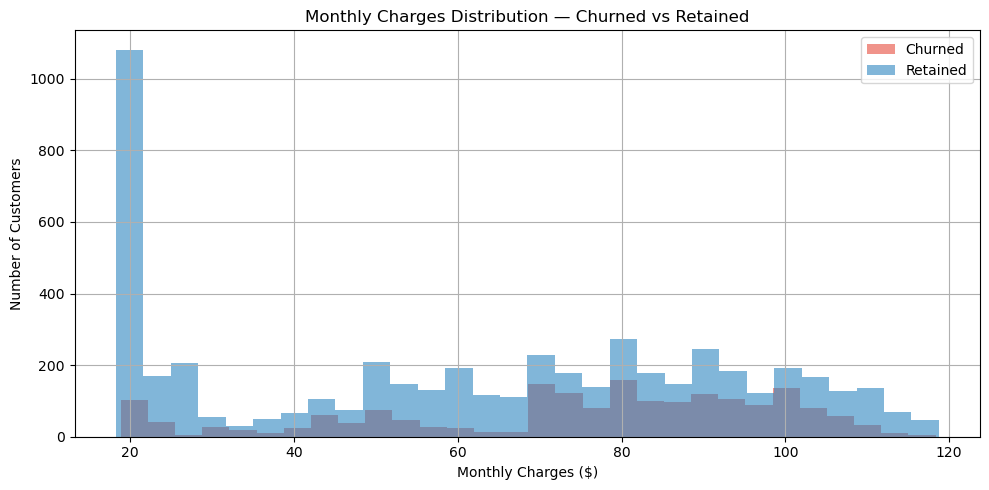


Average monthly charges:
Churn
No    61.27
Yes   74.44
Name: MonthlyCharges, dtype: float64


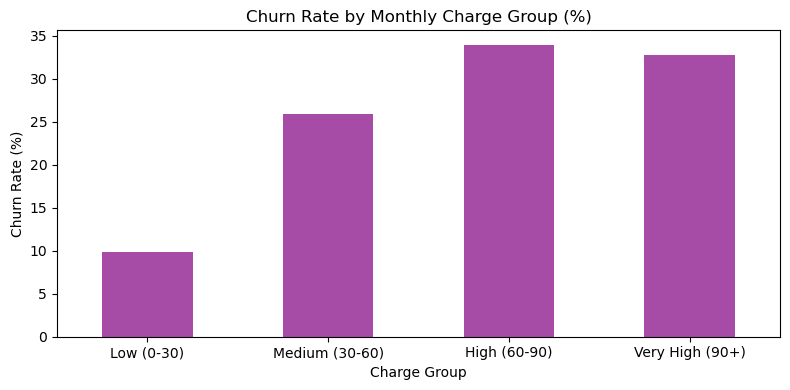

In [10]:
# SECTION 7: MONTHLY CHARGES ANALYSIS
# 7.1 Monthly charges distribution by churn
plt.figure(figsize=(10, 5))
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(
    bins=30, alpha=0.6, color='#E74C3C', label='Churned'
)
df[df['Churn'] == 'No']['MonthlyCharges'].hist(
    bins=30, alpha=0.6, color='#2E86C1', label='Retained'
)
plt.title('Monthly Charges Distribution — Churned vs Retained')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

# 7.2 Average monthly charges by churn status
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print("\nAverage monthly charges:")
print(avg_charges)

# 7.3 Churn rate by Charge Group
charge_churn = df.groupby('Charge_Group', observed=True)['Churn_Flag'].mean() * 100

plt.figure(figsize=(8, 4))
charge_churn.plot(kind='bar', color='purple', alpha=0.7)
plt.title('Churn Rate by Monthly Charge Group (%)')
plt.xlabel('Charge Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Churn rate by gender:
gender
Female   26.92
Male     26.16
Name: Churn_Flag, dtype: float64

Churn rate by Senior Citizen status:
SeniorCitizen
No    23.61
Yes   41.68
Name: Churn_Flag, dtype: float64

Churn rate by Partner status:
Partner
No    32.96
Yes   19.66
Name: Churn_Flag, dtype: float64

Churn rate by Dependents status:
Dependents
No    31.28
Yes   15.45
Name: Churn_Flag, dtype: float64


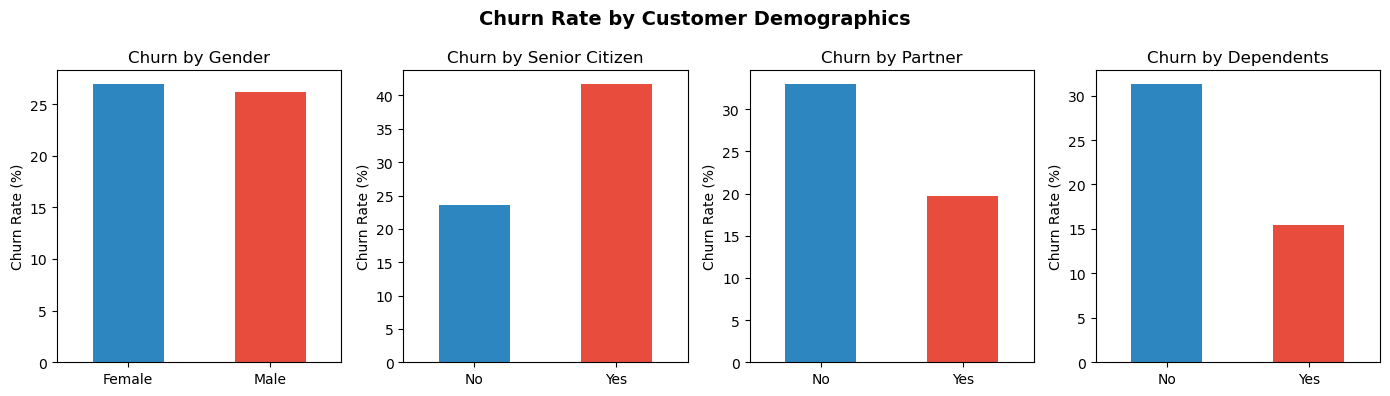

In [11]:
# SECTION 8: CUSTOMER SEGMENT ANALYSIS
# 8.1 Churn by gender
gender_churn = df.groupby('gender')['Churn_Flag'].mean() * 100
print("\nChurn rate by gender:")
print(gender_churn)

# 8.2 Churn by Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn_Flag'].mean() * 100
print("\nChurn rate by Senior Citizen status:")
print(senior_churn)

# 8.3 Churn by Partner status
partner_churn = df.groupby('Partner')['Churn_Flag'].mean() * 100
print("\nChurn rate by Partner status:")
print(partner_churn)

# 8.4 Churn by Dependents
dependent_churn = df.groupby('Dependents')['Churn_Flag'].mean() * 100
print("\nChurn rate by Dependents status:")
print(dependent_churn)

# 8.5 Plot segment churn rates
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (col, title) in zip(axes, [
    ('gender', 'Gender'),
    ('SeniorCitizen', 'Senior Citizen'),
    ('Partner', 'Partner'),
    ('Dependents', 'Dependents')
]):
    churn_rate = df.groupby(col)['Churn_Flag'].mean() * 100
    churn_rate.plot(kind='bar', ax=ax, color=['#2E86C1', '#E74C3C'])
    ax.set_title(f'Churn by {title}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Churn Rate by Customer Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# SECTION 9: SERVICE ANALYSIS
# 9.1 Churn by Paperless Billing
paperless_churn = df.groupby('PaperlessBilling')['Churn_Flag'].mean() * 100
print("\nChurn rate by Paperless Billing:")
print(paperless_churn)

# 9.2 Churn by Tech Support
techsupport_churn = df.groupby('TechSupport')['Churn_Flag'].mean() * 100
print("\nChurn rate by Tech Support:")
print(techsupport_churn)

# 9.3 Churn by Online Security
security_churn = df.groupby('OnlineSecurity')['Churn_Flag'].mean() * 100
print("\nChurn rate by Online Security:")
print(security_churn)


Churn rate by Paperless Billing:
PaperlessBilling
No    16.33
Yes   33.57
Name: Churn_Flag, dtype: float64

Churn rate by Tech Support:
TechSupport
No                    41.64
No internet service    7.40
Yes                   15.17
Name: Churn_Flag, dtype: float64

Churn rate by Online Security:
OnlineSecurity
No                    41.77
No internet service    7.40
Yes                   14.61
Name: Churn_Flag, dtype: float64


In [13]:
# SECTION 10: KEY SUMMARY STATISTICS
print("\n--- KEY SUMMARY ---")
print(f"Total customers: {len(df):,}")
print(f"Churned customers: {df['Churn_Flag'].sum():,}")
print(f"Retained customers: {(df['Churn_Flag'] == 0).sum():,}")
print(f"Overall churn rate: {df['Churn_Flag'].mean() * 100:.1f}%")
print(f"Average tenure — Churned: {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"Average tenure — Retained: {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"Average monthly charge — Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Average monthly charge — Retained: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")


--- KEY SUMMARY ---
Total customers: 7,043
Churned customers: 1,869
Retained customers: 5,174
Overall churn rate: 26.5%
Average tenure — Churned: 18.0 months
Average tenure — Retained: 37.6 months
Average monthly charge — Churned: $74.44
Average monthly charge — Retained: $61.27


In [14]:
# SECTION 11: SAVE CLEANED DATA FOR POWER BI
output_file = 'cleaned_churn_data.csv'
df.to_csv(output_file, index=False)
print(f"\nCleaned data saved as '{output_file}'")
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())


Cleaned data saved as 'cleaned_churn_data.csv'
Final shape: (7043, 24)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Flag', 'Tenure_Group', 'Charge_Group']
